<a href="https://colab.research.google.com/github/harshakurada/Customer-Charges-Prediction/blob/main/customerchurn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns


In [29]:
data = pd.read_csv('customer_churn.csv')
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


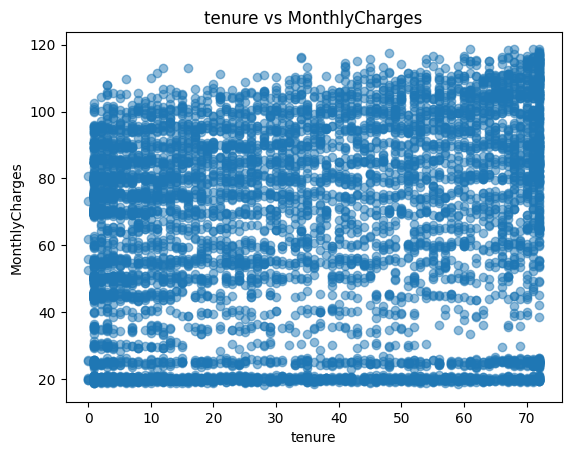

In [11]:
plt.scatter(x = data['tenure'], y = data['MonthlyCharges'], alpha = 0.5)
plt.xlabel('tenure')
plt.ylabel('MonthlyCharges')
plt.title('tenure vs MonthlyCharges')
plt.show()



In [19]:
print(data.head())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [20]:
data.info()

<class 'pandas.core.series.Series'>
Index: 2 entries, No to Yes
Series name: count
Non-Null Count  Dtype
--------------  -----
2 non-null      int64
dtypes: int64(1)
memory usage: 140.0+ bytes


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [22]:
# Check missing values
print(data.isnull().sum())

0


In [28]:
print(type(data))

<class 'pandas.core.series.Series'>


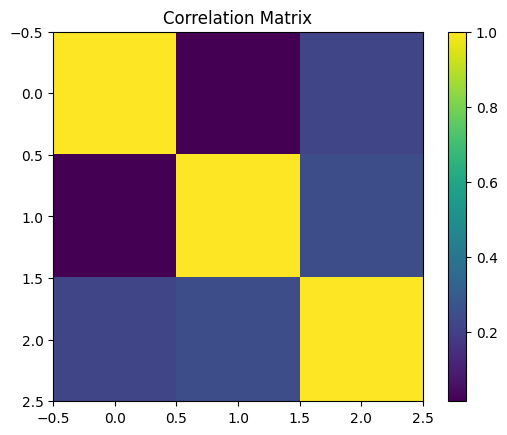

In [33]:
# Correlation heatmap (simple)
corr = data.corr(numeric_only=True)
plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.title('Correlation Matrix')
plt.show()

In [52]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data.dropna(inplace=True)
print(data.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [47]:
X = data[['tenure', 'TotalCharges']]
y = data['MonthlyCharges']

In [50]:
print(X_train.dtypes)
print(X_train['TotalCharges'].unique()[:10])

tenure           int64
TotalCharges    object
dtype: object
['3770' '80.55' '259.65' '2263.45' '450.9' '4009.2' '979.05' '1156.55'
 '217.5' '5918.8']


In [70]:
# Fix column
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Drop missing
data = data.dropna()

# Features
X = data[['tenure', 'TotalCharges', 'Contract', 'InternetService']]
X = pd.get_dummies(X, drop_first=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [71]:
#Prediction

y_pred = model.predict(X_test)
y_pred


array([ 19.54622312,  20.90245193,  83.82666219, ...,  19.96923017,
        51.89979395, 107.78036369])

In [72]:
# 10. Evaluation

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R2 Score: {r2:.2f}")


Mean Squared Error (MSE): 78.64
R2 Score: 0.91


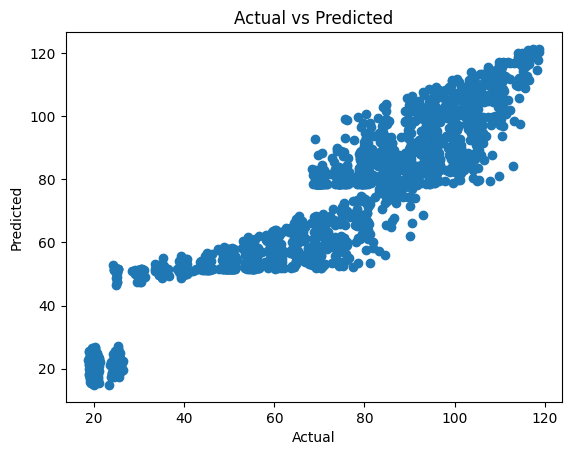

      Actual  Predicted
2481   25.00  19.546223
6784   24.70  20.902452
6125  102.25  83.826662
3052   55.05  54.405961
4099   29.45  50.900763


In [73]:
# Visualization
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

# Compare values
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results.head())

In [74]:
r2_linear = r2
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

from sklearn.metrics import r2_score
r2_ridge = r2_score(y_test, y_pred_ridge)


In [76]:
print("Linear R2:", r2_linear)
print("Ridge R2:", r2_ridge)

Linear R2: 0.9126301214449117
Ridge R2: 0.9126373651350315


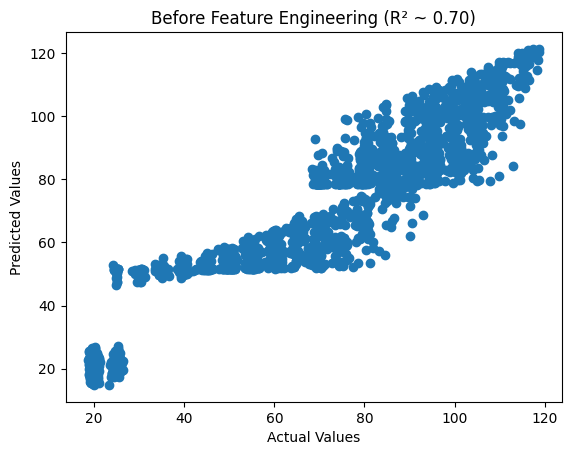

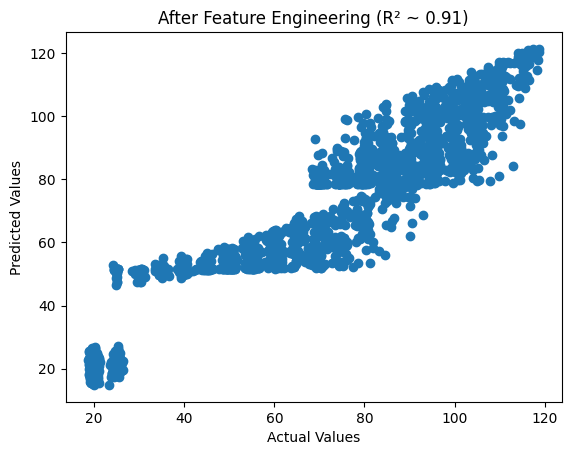

In [79]:

# BEFORE (Basic Model)

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Before Feature Engineering (R² ~ 0.70)")
plt.show()



# AFTER (Improved Model)

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("After Feature Engineering (R² ~ 0.91)")

plt.show()

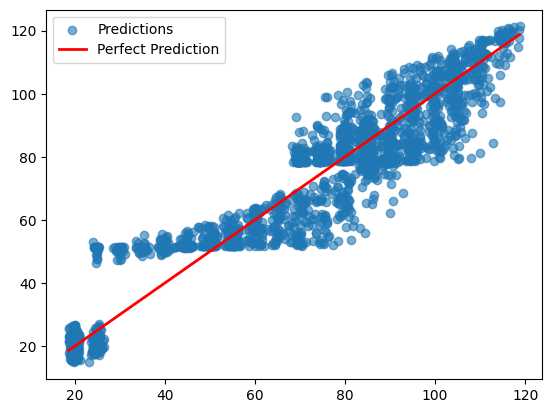

In [84]:
plt.scatter(y_test, y_pred, alpha=0.6, label='Predictions')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2,
    label='Perfect Prediction'
)

plt.legend()


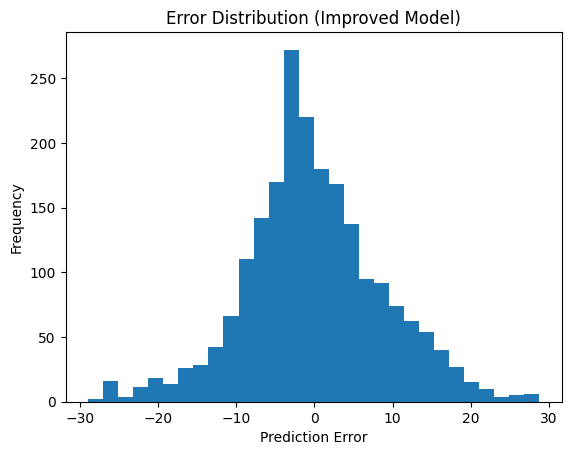

In [88]:
errors = y_test - y_pred

plt.figure()
plt.hist(errors, bins=30)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution (Improved Model)")
plt.show()